# NFL Coaching Career Movement Prediction

This notebook analyzes NFL coaching career trajectories and predicts whether a coach will be promoted, demoted, move sideways, or exit the league.

## 1. Imports & Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_selection import f_classif
from sklearn.inspection import permutation_importance

from imblearn.over_sampling import SMOTE
from collections import Counter

import nflreadpy as nfl
import warnings
warnings.filterwarnings('ignore')

print("All imports loaded successfully.")


All imports loaded successfully.


## 2. Data Loading & Team Name Mapping

In [4]:
# Load NFL team mapping
teams = nfl.load_teams()
mapping = dict(zip(teams['team_abbr'], teams['team_name']))

# Load coaching dataset and team stats
df = pd.read_stata("coach list 89-25 with race.dta")
df2 = pd.read_csv("team_stats_2003_2023.csv")

print(f"Coaching data: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Team stats: {df2.shape[0]} rows, {df2.shape[1]} columns")
df.head(3)


Coaching data: 14745 rows, 7 columns
Team stats: 672 rows, 35 columns


,Team,Year,Role,CoachName,DOB,Race,Played
0,ARI,1986,HC,G. Stallings,1935-03-02,W,0.0
1,ARI,1986,OC,J. Shofner,1935-12-18,W,1.0
2,ARI,1987,HC,G. Stallings,1935-03-02,W,0.0


In [5]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 35 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  672 non-null    int64  
 1   team                  672 non-null    object 
 2   wins                  672 non-null    int64  
 3   losses                672 non-null    int64  
 4   win_loss_perc         672 non-null    float64
 5   points                672 non-null    int64  
 6   points_opp            672 non-null    int64  
 7   points_diff           672 non-null    int64  
 8   mov                   352 non-null    float64
 9   g                     672 non-null    int64  
 10  total_yards           672 non-null    int64  
 11  plays_offense         672 non-null    int64  
 12  yds_per_play_offense  672 non-null    float64
 13  turnovers             672 non-null    int64  
 14  fumbles_lost          672 non-null    int64  
 15  first_down            6

## 3. Data Cleaning & Merging

In [6]:
#Translate team abbreviations to full names, accounting for franchise relocations
def get_historical_name(row):
    translations = {
        'GNB': 'GB', 'KAN': 'KC', 'NEW': 'NE', 
        'NOR': 'NO', 'SFO': 'SF', 'TAM': 'TB'
    }
    abbr = translations.get(row['Team'], row['Team'])
    year = row['Year']
    
    if abbr == 'WAS':
        if year <= 2019: return 'Washington Redskins'
        if year <= 2021: return 'Washington Football Team'
        return 'Washington Commanders'
    if abbr in ['STL', 'LA', 'LAR']:
        return 'St. Louis Rams' if year <= 2015 else 'Los Angeles Rams'
    if abbr in ['SD', 'LAC']:
        return 'San Diego Chargers' if year <= 2016 else 'Los Angeles Chargers'
    if abbr in ['OAK', 'LV']:
        return 'Oakland Raiders' if year <= 2019 else 'Las Vegas Raiders'
    return mapping.get(abbr)


In [7]:
# Create unique coach ID and experience counter
df['CoachID'] = df['CoachName'] + "_" + df['DOB'].astype(str)
df = df.sort_values(['CoachID', 'Year'])
df['Experience'] = df.groupby('CoachID').cumcount()

# Filter to 2003+ and standardize team names
df_filtered = df[df['Year'] >= 2003].copy()
df_filtered['FullTeamName'] = df_filtered.apply(get_historical_name, axis=1)

# Merge coaching data with team stats
merged_df = pd.merge(
    df_filtered, df2,
    left_on=['Year', 'FullTeamName'], right_on=['year', 'team'],
    how='left'
).drop(columns=['year', 'team'])

print(f"Missing FullTeamNames: {merged_df['FullTeamName'].isnull().sum()}")
print(f"Merged dataset: {merged_df.shape}")


Missing FullTeamNames: 0
Merged dataset: (9733, 43)


In [8]:
# Convert ties to half-wins/half-losses and drop the ties column
has_tie = merged_df['ties'] > 0
merged_df.loc[has_tie, 'wins'] += merged_df['ties'] * 0.5
merged_df.loc[has_tie, 'losses'] += merged_df['ties'] * 0.5
merged_df = merged_df.drop(columns=['ties'])

# Drop rows with missing coach names
merged_df['CoachName'] = merged_df['CoachName'].replace('', pd.NA)
merged_df = merged_df.dropna(subset=['CoachName'])

print(f"Dataset size after cleaning: {len(merged_df)} rows")
print(f"Unique coaches: {merged_df['CoachID'].nunique()}")


Dataset size after cleaning: 9725 rows
Unique coaches: 1324


## 4. Feature Engineering

### 4a. Role Hierarchy, Movement Labels & Race Encoding

In [9]:
# Define 3-tier coaching hierarchy
original_hierarchy = {
    'HC': 3,
    'OC': 2, 'DC': 2, 'ST': 2,
    'QB': 1,
    'DL': 1, 'WR': 1, 'DB': 1, 'RB': 1,
    'LB': 1, 'OL': 1, 'TE': 1
}

merged_df['Tier'] = merged_df['Role'].map(original_hierarchy)

# Calculate forward-looking movement labels
merged_df = merged_df.sort_values(['CoachID', 'Year'])
merged_df['Next_Tier'] = merged_df.groupby('CoachID')['Tier'].shift(-1)
merged_df['Next_Year'] = merged_df.groupby('CoachID')['Year'].shift(-1)

def calculate_forward_movement(row):
    if pd.isna(row['Next_Tier']) or (row['Next_Year'] - row['Year'] > 1):
        return 'Exit/Gap'
    if row['Next_Tier'] > row['Tier']:
        return 'Promotion'
    elif row['Next_Tier'] < row['Tier']:
        return 'Demotion'
    return 'Sideways'

merged_df['Movement'] = merged_df.apply(calculate_forward_movement, axis=1)

print("Original Movement distribution:")
print(merged_df['Movement'].value_counts())


Original Movement distribution:
Movement
Sideways     6988
Exit/Gap     1940
Promotion     496
Demotion      301
Name: count, dtype: int64


In [10]:
# 2025 demographics snapshot (before filtering)
df_2025 = merged_df[merged_df['Year'] == 2025]
label_map = {'W': 'White', 'B': 'Black', 'M': 'Mixed/Other', '0': 'Unknown'}
print("--- 2025 Coaching Demographics ---")
for race_val, count in df_2025['Race'].value_counts().items():
    pct = count / len(df_2025) * 100
    print(f"{label_map.get(race_val, race_val)}: {count} ({pct:.1f}%)")

# Keep only White (W) and Black (B) coaches, encode as 0/1
merged_df = merged_df[merged_df['Race'].isin(['W', 'B'])].copy()
merged_df['Race'] = merged_df['Race'].map({'W': 0, 'B': 1})

print(f"\nAfter race filtering: {len(merged_df)} rows")
print(merged_df['Race'].value_counts().rename({0: 'White', 1: 'Black'}))


--- 2025 Coaching Demographics ---
White: 250 (58.4%)
Black: 177 (41.4%)
Mixed/Other: 1 (0.2%)

After race filtering: 9606 rows
Race
White    6352
Black    3254
Name: count, dtype: int64


### 4b. Statistical Positionality Score

In [11]:
#Define relevant statistics for each position
relevant_stats = {
    'HC': ['win_loss_perc', 'mov', 'points_diff', 'wins'],
    'OC': ['points', 'score_pct', 'exp_pts_tot'],
    'DC': ['points_opp', 'turnover_pct'],
    'QB': ['pass_yds', 'pass_td', 'pass_cmp_perc', 'pass_int', 'pass_fd'],
    'RB': ['rush_yds', 'rush_td', 'rush_yds_per_att', 'rush_fd'],
    'WR': ['pass_yds', 'pass_td', 'pass_fd'],
    'TE': ['pass_yds', 'pass_td', 'pass_fd'],
    'OL': ['rush_yds_per_att', 'rush_att', 'penalties'],
    'DL': ['points_opp'], 'LB': ['points_opp'], 
    'DB': ['points_opp', 'pass_int'],
}

def calculate_statistical_positionality(df):
    df['statistical_positionality'] = 0.0
    inverse_stats = {'points_opp', 'pass_int', 'penalties', 'penalties_yds'}
    
    for (year, role), group in df.groupby(['Year', 'Role']):
        if role not in relevant_stats:
            continue
        stats_to_check = [s for s in relevant_stats[role] if s in group.columns]
        if not stats_to_check:
            continue
        
        percentile_ranks = []
        for stat in stats_to_check:
            ascending = stat not in inverse_stats
            percentile_ranks.append(group[stat].rank(pct=True, ascending=ascending))
        
        avg_percentile = pd.concat(percentile_ranks, axis=1).mean(axis=1)
        df.loc[avg_percentile.index, 'statistical_positionality'] = avg_percentile
    return df

merged_df = calculate_statistical_positionality(merged_df)
print(merged_df[['CoachName', 'Year', 'Role', 'statistical_positionality']].sample(5))


        CoachName  Year Role  statistical_positionality
4659    J. Porter  2016   LB                   0.761364
2569      D. Toub  2014   ST                   0.000000
8014   R. Sherman  2003   WR                   0.681818
7792    R. Melvin  2005   DL                   0.694444
523   B. April Jr  2007   ST                   0.000000


### 4c. League-Wide Churn Rate Feature

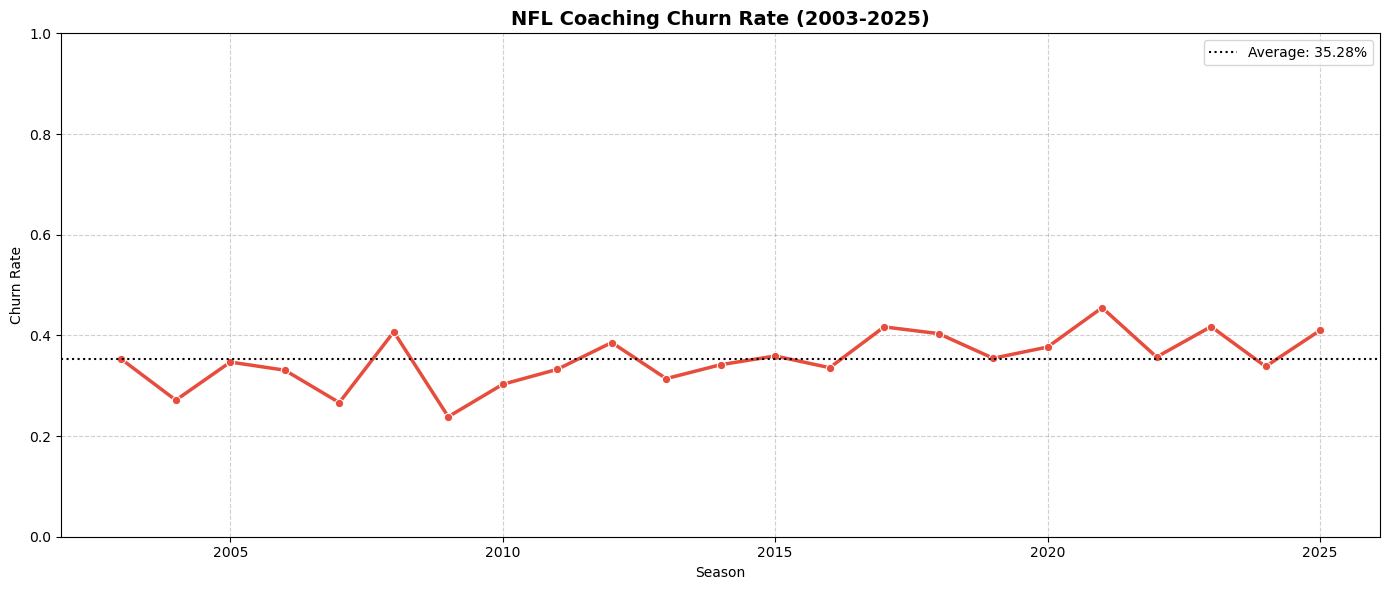

In [12]:
def calculate_seasonal_churn(df):
    churn_data = []
    df_sorted = df.sort_values(['FullTeamName', 'Role', 'Year'])
    years = sorted(df_sorted['Year'].unique())
    
    for i in range(len(years) - 1):
        current = df_sorted[df_sorted['Year'] == years[i]][['CoachID', 'FullTeamName', 'Role']]
        next_yr = df_sorted[df_sorted['Year'] == years[i+1]][['CoachID', 'FullTeamName', 'Role']]
        returned = pd.merge(current, next_yr, on=['CoachID', 'FullTeamName', 'Role'])
        
        total = len(current)
        persistence = len(returned) / total if total > 0 else 0
        churn_data.append({
            'Year': years[i], 'Next_Year': years[i+1],
            'Churn_Rate': 1 - persistence, 'Total_Coaches': total, 'Returned': len(returned)
        })
    return pd.DataFrame(churn_data)

churn_df = calculate_seasonal_churn(merged_df)

# Map previous year's churn as a feature
churn_lookup = churn_df[['Next_Year', 'Churn_Rate']].copy()
churn_lookup['Target_Year'] = churn_lookup['Next_Year'] + 1
churn_lookup = churn_lookup.rename(columns={'Churn_Rate': 'prev_league_churn'})

merged_df = pd.merge(
    merged_df, churn_lookup[['Target_Year', 'prev_league_churn']],
    left_on='Year', right_on='Target_Year', how='left'
).drop(columns=['Target_Year'])
merged_df['prev_league_churn'] = merged_df['prev_league_churn'].fillna(merged_df['prev_league_churn'].mean())

# Visualization
plt.figure(figsize=(14, 6))
sns.lineplot(data=churn_df, x='Year', y='Churn_Rate', marker='o', color='#e74c3c', linewidth=2.5)
mean_churn = churn_df['Churn_Rate'].mean()
plt.axhline(mean_churn, color='black', linestyle=':', label=f'Average: {mean_churn:.2%}')
plt.title('NFL Coaching Churn Rate (2003-2025)', fontsize=14, fontweight='bold')
plt.ylabel('Churn Rate'); plt.xlabel('Season'); plt.ylim(0, 1)
plt.legend(); plt.grid(True, linestyle='--', alpha=0.6); plt.tight_layout(); plt.show()


## 5. Exploratory Data Analysis

In [13]:
merged_df.describe()


,Year,DOB,Race,Played,Experience,wins,losses,win_loss_perc,points,points_opp,...,penalties_yds,pen_fd,score_pct,turnover_pct,exp_pts_tot,Tier,Next_Tier,Next_Year,statistical_positionality,prev_league_churn
count,9606.000000,9606,9606.000000,9606.000000,9606.000000,8384.000000,8384.000000,8384.000000,8384.000000,8384.000000,...,8384.000000,8384.000000,8384.000000,8384.000000,8384.000000,9606.000000,8338.000000,8338.000000,8478.000000,9606.000000
mean,2014.629815,1966-11-13 15:21:46.433479088,0.338747,0.292109,8.881324,8.089695,8.054151,0.501338,359.327409,358.755725,...,850.070253,27.970301,34.166400,12.547555,-34.072402,1.393088,1.419525,2015.141401,0.468979,0.350858
min,2003.000000,1927-01-24 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,168.000000,201.000000,...,415.000000,9.000000,16.400000,4.000000,-358.270000,1.000000,1.000000,2003.000000,0.000000,0.238342
25%,2009.000000,1958-06-22 00:00:00,0.000000,0.000000,3.000000,6.000000,6.000000,0.375000,306.000000,317.000000,...,752.000000,23.000000,29.400000,10.200000,-121.175000,1.000000,1.000000,2009.000000,0.250000,0.332487
50%,2015.000000,1966-10-15 00:00:00,0.000000,0.000000,7.000000,8.000000,8.000000,0.500000,359.000000,358.000000,...,853.000000,28.000000,34.000000,12.400000,-39.550000,1.000000,1.000000,2015.000000,0.476562,0.350858
75%,2021.000000,1976-03-09 00:00:00,1.000000,1.000000,14.000000,10.000000,10.000000,0.625000,406.000000,398.000000,...,941.250000,33.000000,38.800000,14.800000,52.610000,2.000000,2.000000,2021.000000,0.690411,0.385787
max,2026.000000,1999-04-02 00:00:00,1.000000,1.000000,43.000000,16.000000,16.000000,1.000000,606.000000,519.000000,...,1358.000000,50.000000,52.700000,25.000000,298.140000,3.000000,3.000000,2026.000000,1.000000,0.454988
std,6.901430,NaN,0.473308,0.454756,7.446542,3.083282,3.086914,0.191180,72.136077,57.602371,...,145.952345,7.259456,6.735813,3.213910,120.770877,0.629626,0.643893,6.621307,0.281645,0.049499


In [14]:
merged_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9606 entries, 0 to 9605
Data columns (total 48 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Team                       9606 non-null   object        
 1   Year                       9606 non-null   int16         
 2   Role                       9606 non-null   object        
 3   CoachName                  9606 non-null   object        
 4   DOB                        9606 non-null   datetime64[ns]
 5   Race                       9606 non-null   int64         
 6   Played                     9606 non-null   float64       
 7   CoachID                    9606 non-null   object        
 8   Experience                 9606 non-null   int64         
 9   FullTeamName               9606 non-null   object        
 10  wins                       8384 non-null   float64       
 11  losses                     8384 non-null   float64       
 12  win_lo

### 5a. Feature Selection (F-Scores)

In [15]:
numerical_features = list(merged_df.select_dtypes(include=['float64', 'int64', 'int16']).columns)

analysis_df = merged_df[merged_df['Movement'] != 'Exit/Gap'].copy()
f_results = {}
for col in numerical_features:
    temp = analysis_df[[col, 'Movement']].dropna()
    if len(temp) > 1 and temp['Movement'].nunique() > 1:
        f_val, p_val = f_classif(temp[[col]], temp['Movement'])
        f_results[col] = f_val[0]

print("Ranked F-Scores for Numerical Features:")
print(pd.Series(f_results).sort_values(ascending=False))


Ranked F-Scores for Numerical Features:
Next_Tier                    492.276102
Tier                         301.511523
wins                          75.520035
win_loss_perc                 74.095192
losses                        72.358530
points_diff                   67.699669
statistical_positionality     52.824600
points                        42.965084
mov                           40.894860
score_pct                     40.024707
points_opp                    36.399549
pass_net_yds_per_att          28.777124
rush_td                       27.864832
total_yards                   27.667171
rush_att                      26.137953
exp_pts_tot                   25.602009
turnovers                     24.560127
turnover_pct                  24.442787
first_down                    24.180927
yds_per_play_offense          23.036002
rush_fd                       21.300450
Race                          20.790316
rush_yds                      19.717612
pass_int                      19.460325


### 5b. Movement by Role & Tier Visualizations

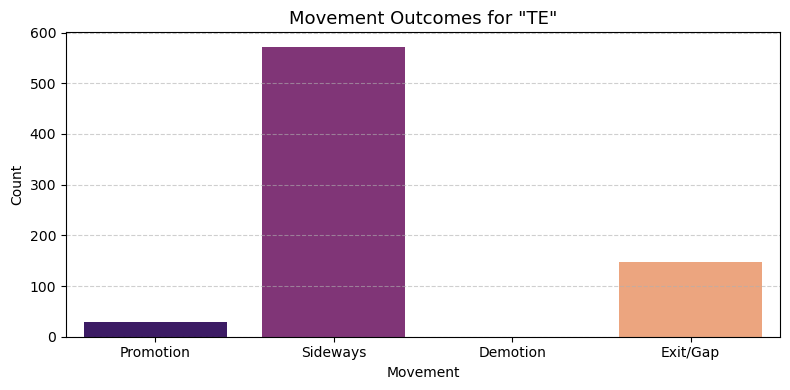

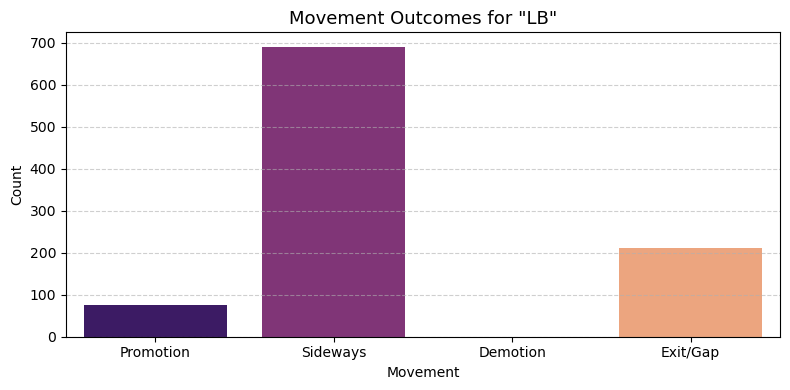

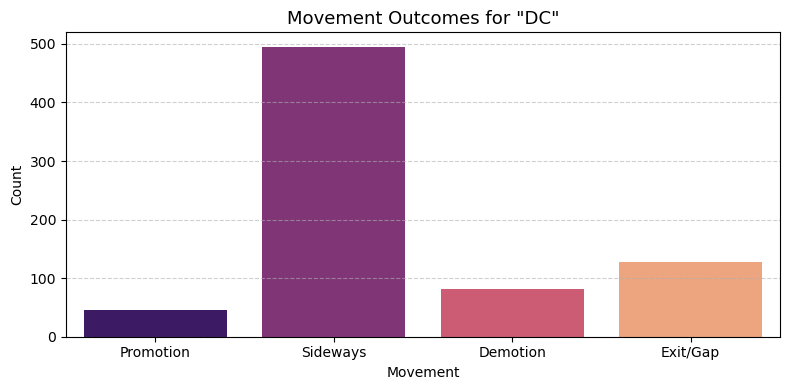

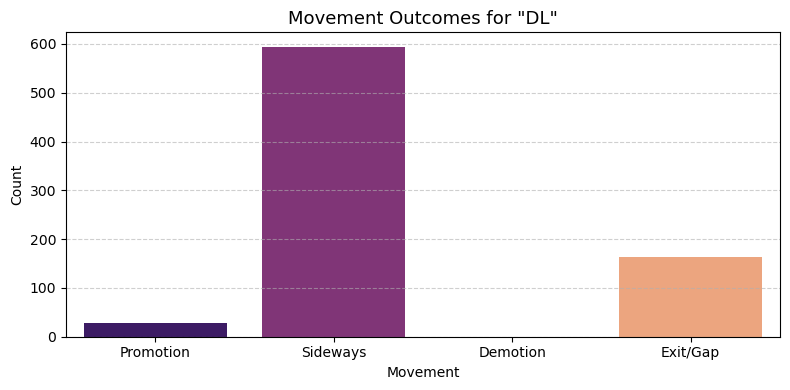

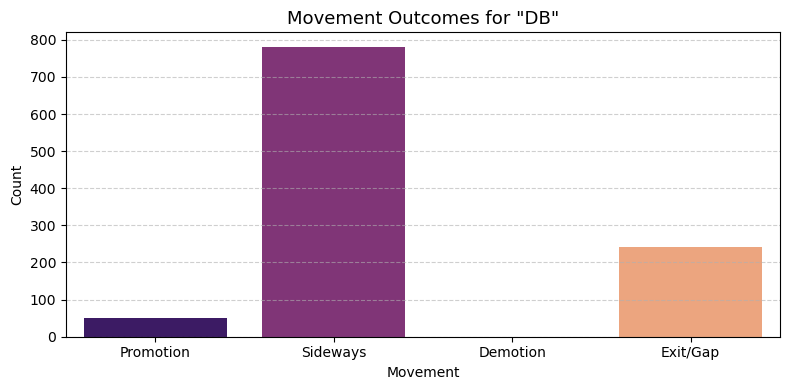

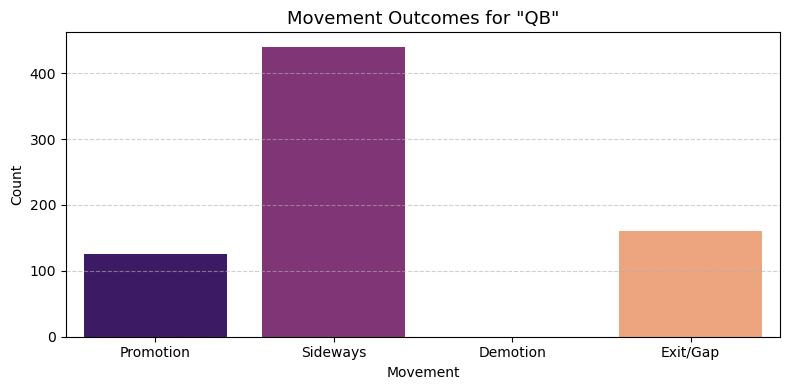

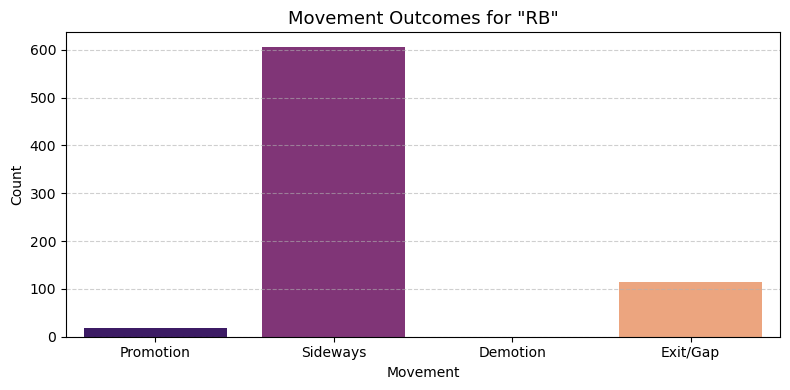

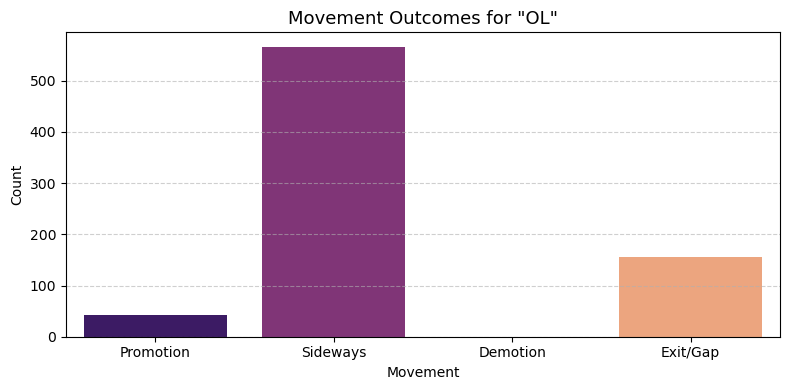

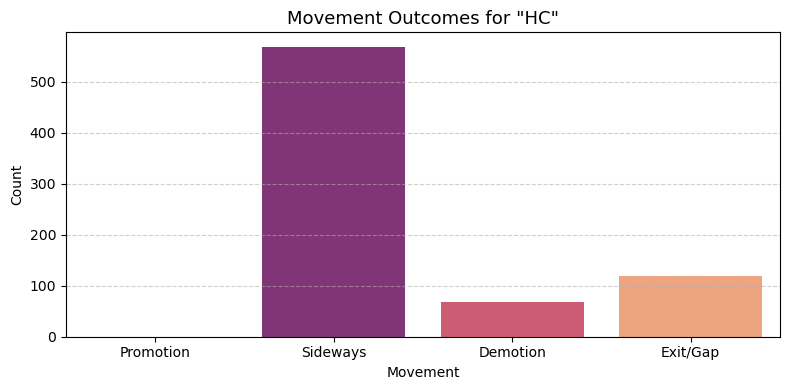

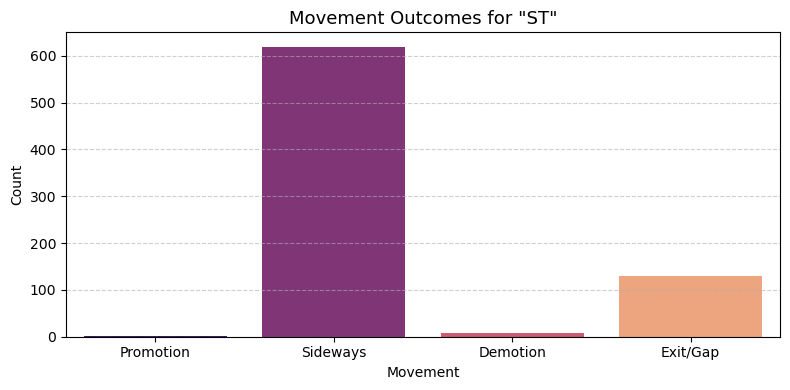

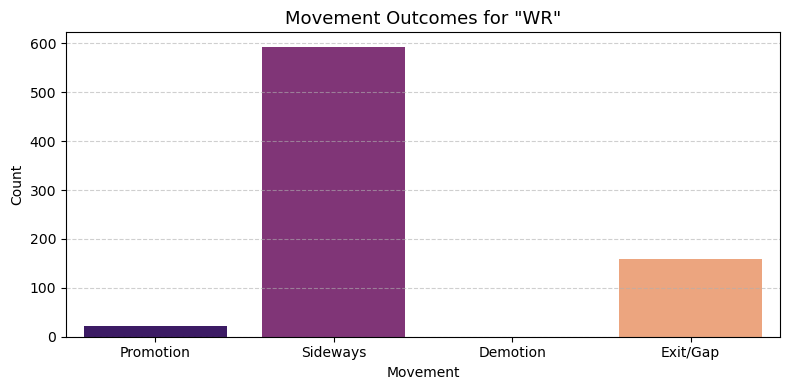

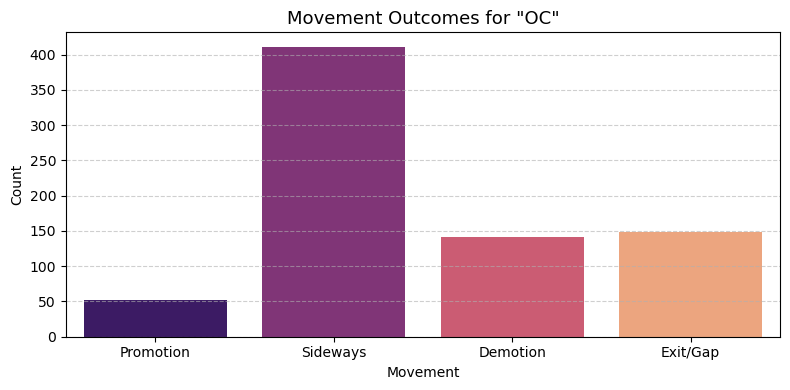

In [16]:
# Movement distribution by role
for role in merged_df['Role'].unique():
    role_df = merged_df[merged_df['Role'] == role]
    if role_df.empty:
        continue
    plt.figure(figsize=(8, 4))
    sns.countplot(data=role_df, x='Movement',
                  order=['Promotion', 'Sideways', 'Demotion', 'Exit/Gap'], palette='magma')
    plt.title(f'Movement Outcomes for "{role}"', fontsize=13)
    plt.xlabel('Movement'); plt.ylabel('Count')
    plt.grid(axis='y', linestyle='--', alpha=0.6); plt.tight_layout(); plt.show()


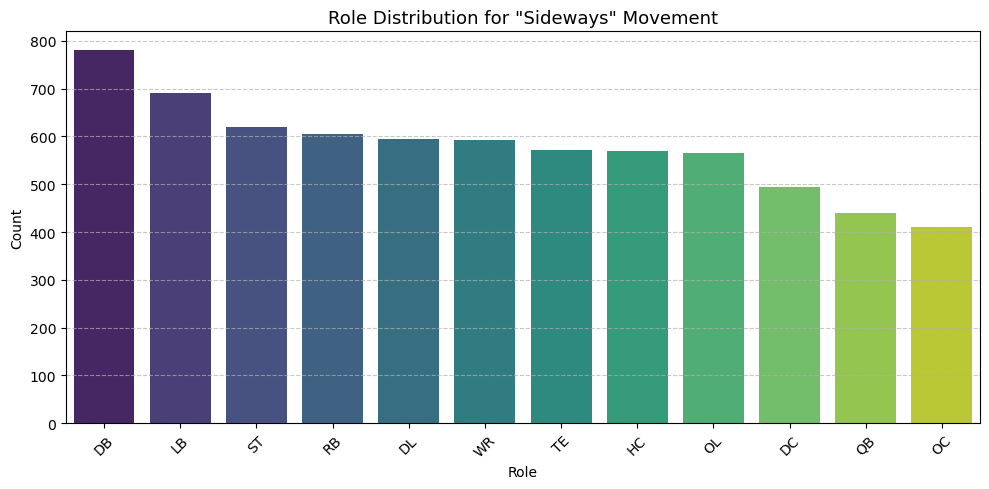

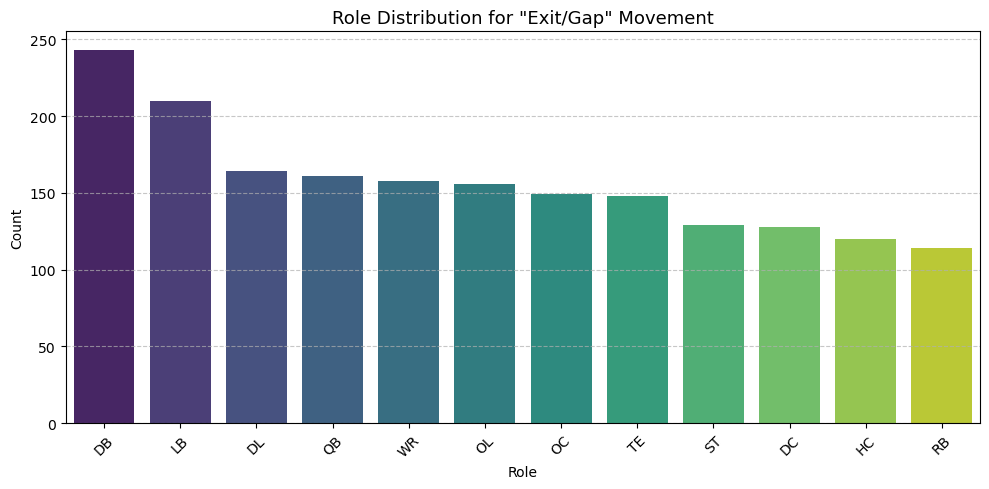

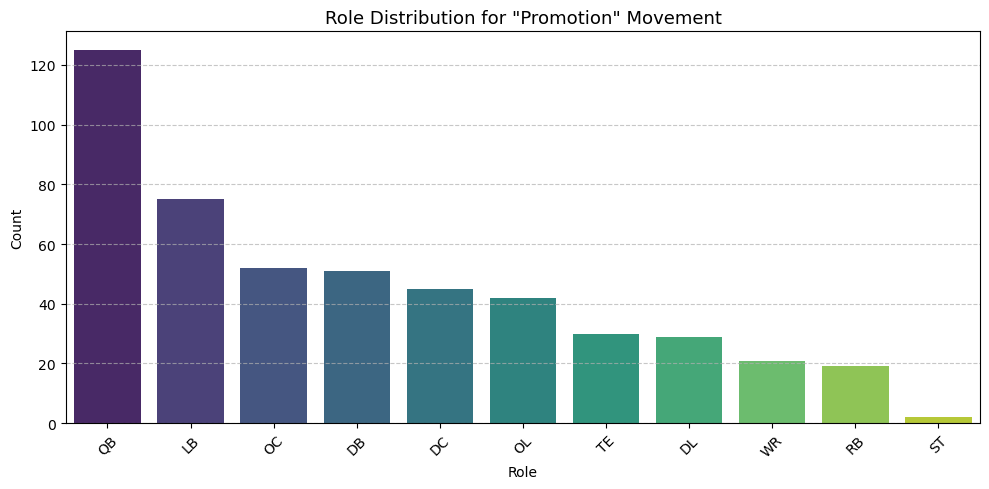

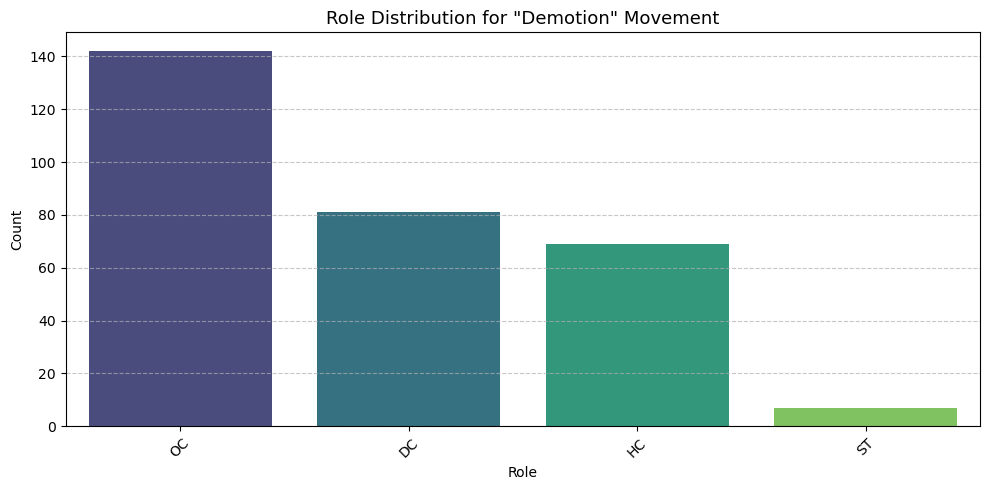

In [17]:
# Role distribution by movement category
for category in merged_df['Movement'].unique():
    cat_df = merged_df[merged_df['Movement'] == category]
    if cat_df.empty:
        continue
    plt.figure(figsize=(10, 5))
    sns.countplot(data=cat_df, x='Role', order=cat_df['Role'].value_counts().index, palette='viridis')
    plt.title(f'Role Distribution for "{category}" Movement', fontsize=13)
    plt.xlabel('Role'); plt.ylabel('Count'); plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7); plt.tight_layout(); plt.show()


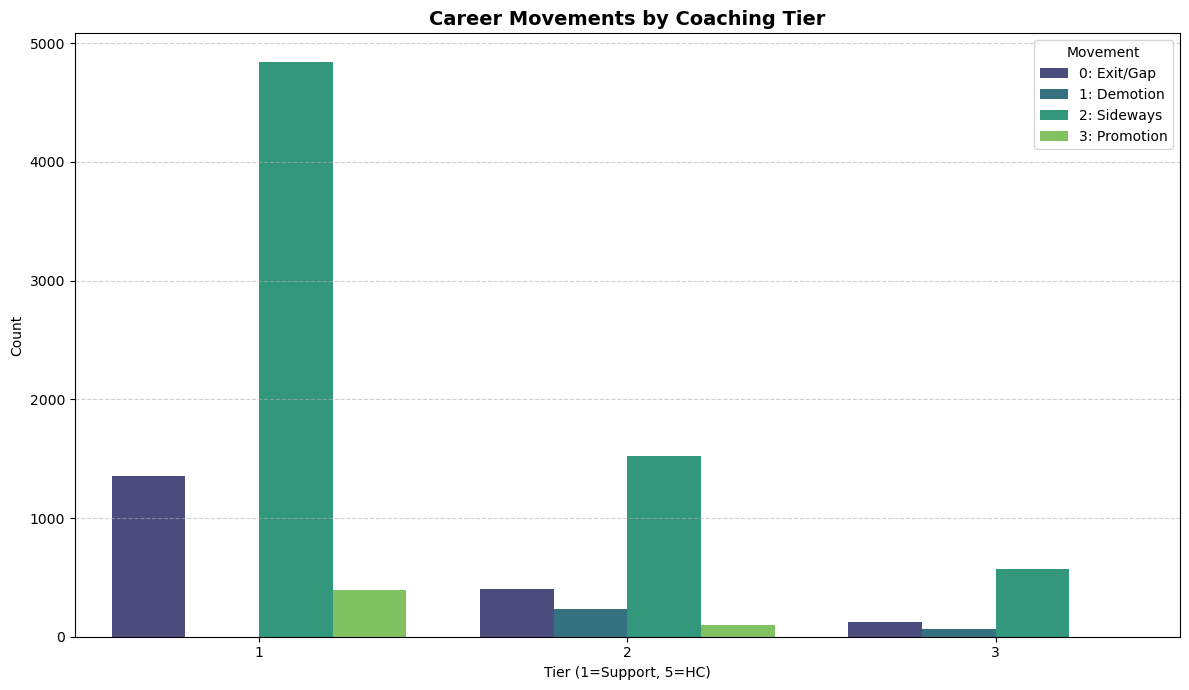

In [18]:
# Movement counts by tier
rank = {'Promotion': 3, 'Sideways': 2, 'Demotion': 1, 'Exit/Gap': 0}
merged_df['Movement_Num'] = merged_df['Movement'].map(rank)

plt.figure(figsize=(12, 7))
sns.countplot(data=merged_df, x='Tier', hue='Movement_Num', palette='viridis')
plt.title('Career Movements by Coaching Tier', fontsize=14, fontweight='bold')
plt.xlabel('Tier (1=Support, 5=HC)'); plt.ylabel('Count')
plt.legend(title='Movement', labels=['0: Exit/Gap', '1: Demotion', '2: Sideways', '3: Promotion'])
plt.grid(axis='y', linestyle='--', alpha=0.6); plt.tight_layout(); plt.show()


## 6. Preprocessing & Model Training



In [19]:
# Define features and target
features = ['Race', 'Tier', 'wins', 'points_diff', 'score_pct', 'mov',
            'statistical_positionality', 'Experience', 'prev_league_churn']

X = merged_df[features]
y = merged_df['Movement']

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")
print(f"\nMissing values in training set:\n{X_train.isnull().sum()}")
print(f"\nClass distribution (train):\n{y_train.value_counts()}")


Training set: (7684, 9), Test set: (1922, 9)

Missing values in training set:
Race                            0
Tier                            0
wins                          992
points_diff                   992
score_pct                     992
mov                          4195
statistical_positionality     915
Experience                      0
prev_league_churn               0
dtype: int64

Class distribution (train):
Movement
Sideways     5548
Exit/Gap     1504
Promotion     393
Demotion      239
Name: count, dtype: int64


### 6a. Define the Preprocessor 




In [20]:
# All features in our set are numerical (Race and Tier are encoded as ints)
numerical_features_list = features  # all features are numeric

# Preprocessing pipeline for numerical features:
# Step 1: Impute missing values with the MEDIAN (robust to outliers)
# Step 2: Standardize features to zero mean and unit variance
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# ColumnTransformer applies the pipeline to the correct columns
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_features_list)
])

print("Preprocessor defined:")
print(preprocessor)


Preprocessor defined:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Race', 'Tier', 'wins', 'points_diff',
                                  'score_pct', 'mov',
                                  'statistical_positionality', 'Experience',
                                  'prev_league_churn'])])


### 6b. Baseline Model Comparison


========================= RANDOM FOREST =========================
              precision    recall  f1-score   support

    Demotion       0.26      0.08      0.13        60
    Exit/Gap       0.58      0.31      0.40       376
   Promotion       0.00      0.00      0.00        98
    Sideways       0.77      0.93      0.84      1388

    accuracy                           0.74      1922
   macro avg       0.40      0.33      0.34      1922
weighted avg       0.67      0.74      0.69      1922

CV Macro-F1: 0.3596 ± 0.0123


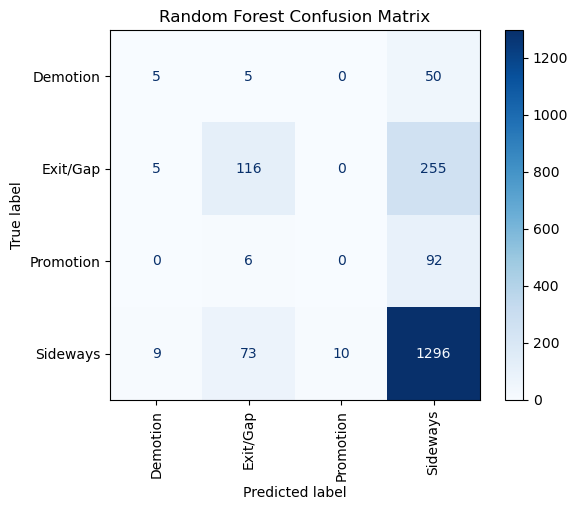

Overall Accuracy: 73.73%

Accuracy by Race (0=White, 1=Black):
Race
0    0.7277
1    0.7567
Name: Correct, dtype: float64

Random Forest Bias Summary (% of errors):


Error_Type,Optimistic,Pessimistic
Race,,
0,60.40,39.60
1,70.13,29.87



Top 3 Mispredictions for Black Coaches (Race=1):
Actual     Predicted
Exit/Gap   Sideways     92
Promotion  Sideways     26
Sideways   Exit/Gap     16
dtype: int64

========================= DECISION TREE =========================
              precision    recall  f1-score   support

    Demotion       0.25      0.35      0.29        60
    Exit/Gap       0.35      0.36      0.36       376
   Promotion       0.05      0.05      0.05        98
    Sideways       0.77      0.76      0.76      1388

    accuracy                           0.63      1922
   macro avg       0.36      0.38      0.36      1922
weighted avg       0.64      0.63      0.63      1922

CV Macro-F1: 0.3764 ± 0.0067


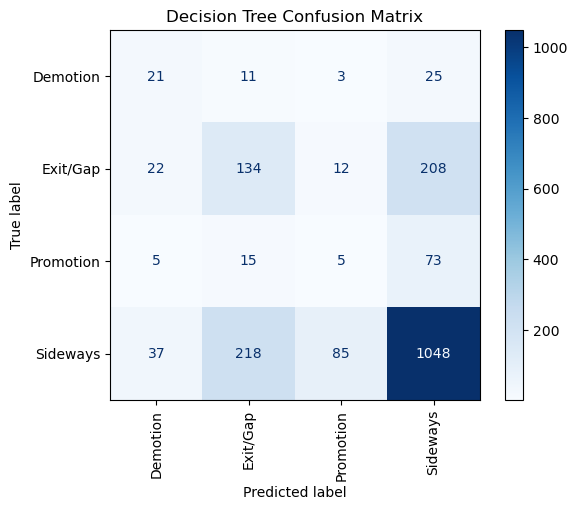

Overall Accuracy: 62.85%

Accuracy by Race (0=White, 1=Black):
Race
0    0.6214
1    0.6430
Name: Correct, dtype: float64

Decision Tree Bias Summary (% of errors):


Error_Type,Optimistic,Pessimistic
Race,,
0,50.20,49.80
1,48.67,51.33



Top 3 Mispredictions for Black Coaches (Race=1):
Actual    Predicted
Sideways  Exit/Gap     77
Exit/Gap  Sideways     73
Sideways  Promotion    24
dtype: int64

========================= NAIVE BAYES =========================
              precision    recall  f1-score   support

    Demotion       0.22      0.32      0.26        60
    Exit/Gap       0.31      0.28      0.30       376
   Promotion       0.33      0.01      0.02        98
    Sideways       0.75      0.81      0.78      1388

    accuracy                           0.65      1922
   macro avg       0.40      0.35      0.34      1922
weighted avg       0.63      0.65      0.63      1922

CV Macro-F1: 0.3222 ± 0.0237


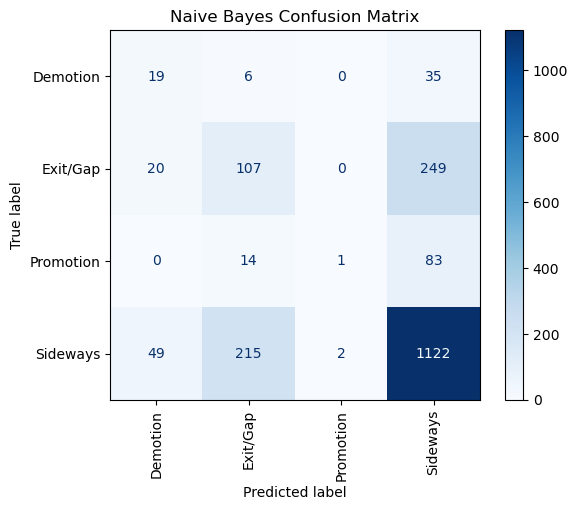

Overall Accuracy: 64.98%

Accuracy by Race (0=White, 1=Black):
Race
0    0.6416
1    0.6667
Name: Correct, dtype: float64

Naive Bayes Bias Summary (% of errors):


Error_Type,Optimistic,Pessimistic
Race,,
0,44.81,55.19
1,46.92,53.08



Top 3 Mispredictions for Black Coaches (Race=1):
Actual     Predicted
Exit/Gap   Sideways     88
Sideways   Exit/Gap     77
Promotion  Sideways     25
dtype: int64

========================= KNN =========================
              precision    recall  f1-score   support

    Demotion       0.21      0.13      0.16        60
    Exit/Gap       0.42      0.28      0.34       376
   Promotion       0.00      0.00      0.00        98
    Sideways       0.77      0.88      0.82      1388

    accuracy                           0.70      1922
   macro avg       0.35      0.33      0.33      1922
weighted avg       0.64      0.70      0.66      1922

CV Macro-F1: 0.3612 ± 0.0155


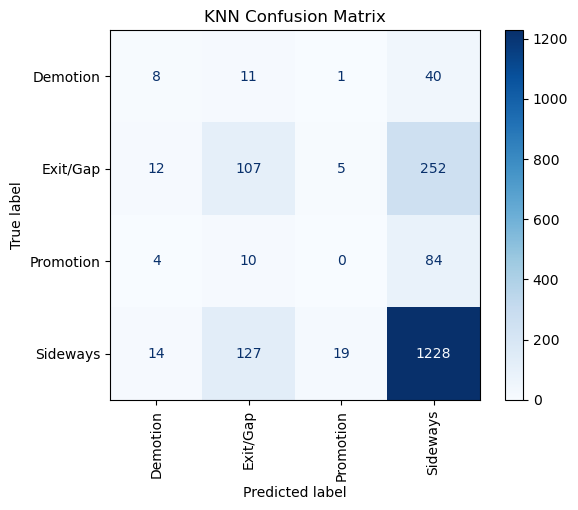

Overall Accuracy: 69.88%

Accuracy by Race (0=White, 1=Black):
Race
0    0.6765
1    0.7441
Name: Correct, dtype: float64

KNN Bias Summary (% of errors):


Error_Type,Optimistic,Pessimistic
Race,,
0,55.16,44.84
1,61.11,38.89



Top 3 Mispredictions for Black Coaches (Race=1):
Actual     Predicted
Exit/Gap   Sideways     88
Sideways   Exit/Gap     25
Promotion  Sideways     24
dtype: int64

========================= LDA =========================
              precision    recall  f1-score   support

    Demotion       0.23      0.13      0.17        60
    Exit/Gap       1.00      0.00      0.01       376
   Promotion       0.00      0.00      0.00        98
    Sideways       0.73      0.99      0.84      1388

    accuracy                           0.72      1922
   macro avg       0.49      0.28      0.25      1922
weighted avg       0.73      0.72      0.61      1922

CV Macro-F1: 0.2484 ± 0.0146


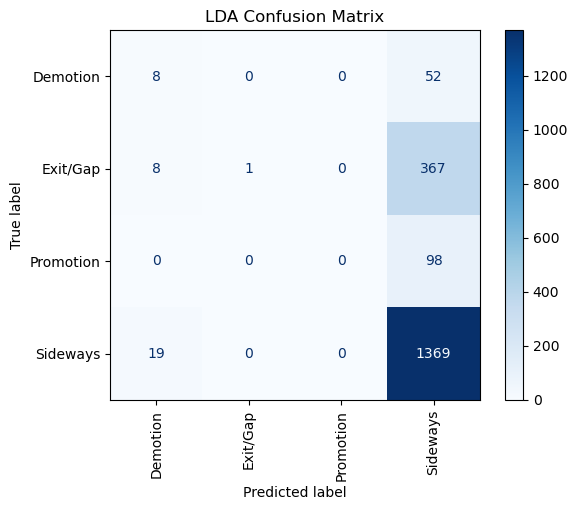

Overall Accuracy: 71.70%

Accuracy by Race (0=White, 1=Black):
Race
0    0.7114
1    0.7283
Name: Correct, dtype: float64

LDA Bias Summary (% of errors):


Error_Type,Optimistic,Pessimistic
Race,,
0,77.15,22.85
1,81.40,18.60



Top 3 Mispredictions for Black Coaches (Race=1):
Actual     Predicted
Exit/Gap   Sideways     127
Promotion  Sideways      29
Demotion   Sideways      11
dtype: int64


In [21]:
# Define models — each wrapped in a Pipeline with the shared preprocessor
model_dict = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "LDA": LinearDiscriminantAnalysis()
}

# Helper: build a full pipeline for each model
def make_pipeline(model):
    return Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

# Train, evaluate, and audit each model
for name, model in model_dict.items():
    pipe = make_pipeline(model)
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    
    # Classification report
    print(f"\n{'='*25} {name.upper()} {'='*25}")
    print(classification_report(y_test, preds))
    
    # Cross-validation score
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='f1_macro')
    print(f"CV Macro-F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    
    # Confusion matrix
    disp = ConfusionMatrixDisplay.from_predictions(
        y_test, preds, display_labels=pipe.classes_, cmap='Blues', xticks_rotation='vertical')
    plt.title(f"{name} Confusion Matrix"); plt.show()
    
    # Bias audit
    df_audit = X_test.copy()
    df_audit['Actual'] = y_test
    df_audit['Predicted'] = preds
    df_audit['Correct'] = df_audit['Actual'] == df_audit['Predicted']
    
    print(f"Overall Accuracy: {df_audit['Correct'].mean():.2%}")
    print("\nAccuracy by Race (0=White, 1=Black):")
    print(df_audit.groupby('Race')['Correct'].mean().round(4))
    
    mis = df_audit[~df_audit['Correct']].copy()
    mis['Actual_Rank'] = mis['Actual'].map(rank)
    mis['Predicted_Rank'] = mis['Predicted'].map(rank)
    mis['Error_Type'] = mis.apply(
        lambda r: 'Optimistic' if r['Predicted_Rank'] > r['Actual_Rank'] else 'Pessimistic', axis=1)
    
    print(f"\n{name} Bias Summary (% of errors):")
    bias_table = mis.groupby(['Race', 'Error_Type']).size().unstack(fill_value=0)
    display(bias_table.div(bias_table.sum(axis=1), axis=0).mul(100).round(2))
    
    print("\nTop 3 Mispredictions for Black Coaches (Race=1):")
    top3 = mis[mis['Race'] == 1].groupby(['Actual', 'Predicted']).size().sort_values(ascending=False).head(3)
    print(top3)


# 6c. Addressing Imbalance

--- SCENARIO 1: CLASS WEIGHT BALANCING AUDIT ---

==================== RANDOM FOREST (BALANCED) ====================
              precision    recall  f1-score   support

    Demotion       0.27      0.12      0.16        60
    Exit/Gap       0.56      0.31      0.40       376
   Promotion       0.05      0.01      0.02        98
    Sideways       0.77      0.92      0.84      1388

    accuracy                           0.73      1922
   macro avg       0.41      0.34      0.35      1922
weighted avg       0.67      0.73      0.69      1922

Overall Accuracy: 72.94%
Accuracy by Race (0=White, 1=Black):
Race
0    0.7339
1    0.7204
Name: Correct, dtype: float64

==================== DECISION TREE (BALANCED) ====================
              precision    recall  f1-score   support

    Demotion       0.21      0.22      0.21        60
    Exit/Gap       0.35      0.36      0.35       376
   Promotion       0.05      0.08      0.06        98
    Sideways       0.76      0.72      0.7

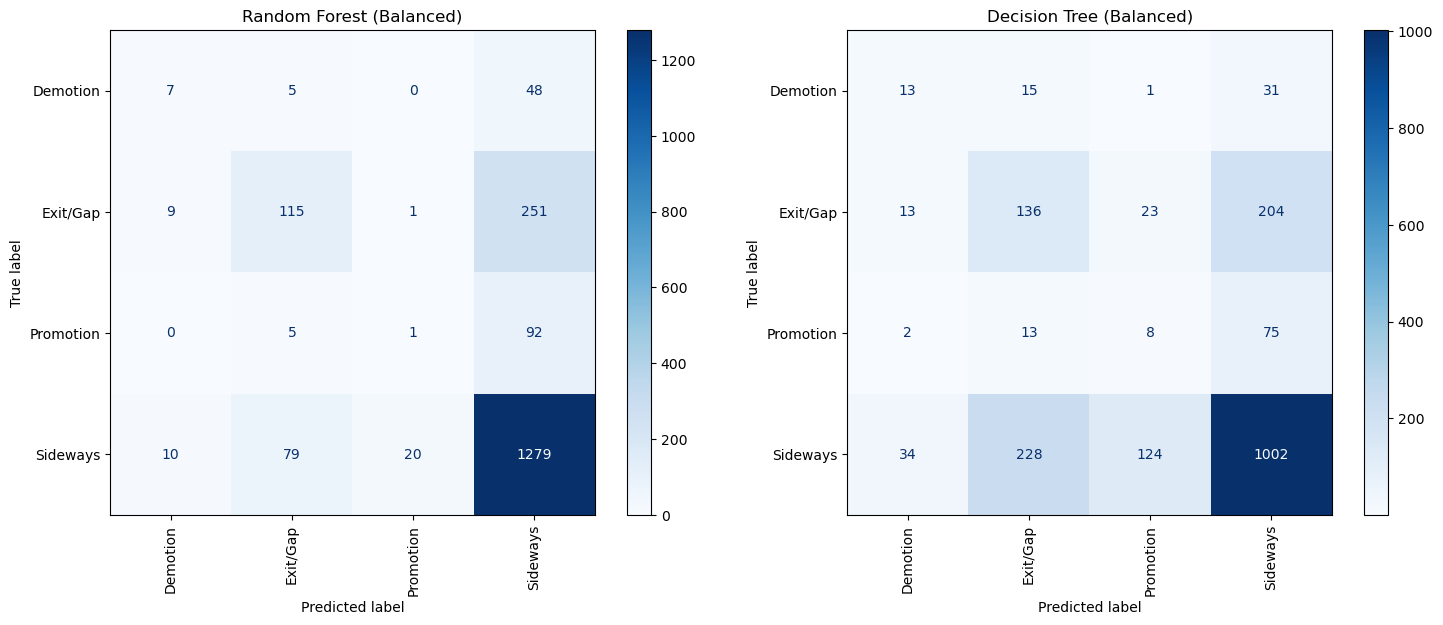


--- SCENARIO 2: SMOTE OVERSAMPLING AUDIT ---

==================== RANDOM FOREST (SMOTE) ====================
              precision    recall  f1-score   support

    Demotion       0.21      0.38      0.27        60
    Exit/Gap       0.46      0.37      0.41       376
   Promotion       0.06      0.04      0.05        98
    Sideways       0.78      0.81      0.80      1388

    accuracy                           0.67      1922
   macro avg       0.38      0.40      0.38      1922
weighted avg       0.66      0.67      0.67      1922

Overall Accuracy: 67.22%
Accuracy by Race (0=White, 1=Black):
Race
0    0.6610
1    0.6951
Name: Correct, dtype: float64

==================== DECISION TREE (SMOTE) ====================
              precision    recall  f1-score   support

    Demotion       0.14      0.25      0.18        60
    Exit/Gap       0.33      0.40      0.36       376
   Promotion       0.08      0.15      0.11        98
    Sideways       0.78      0.66      0.71      13

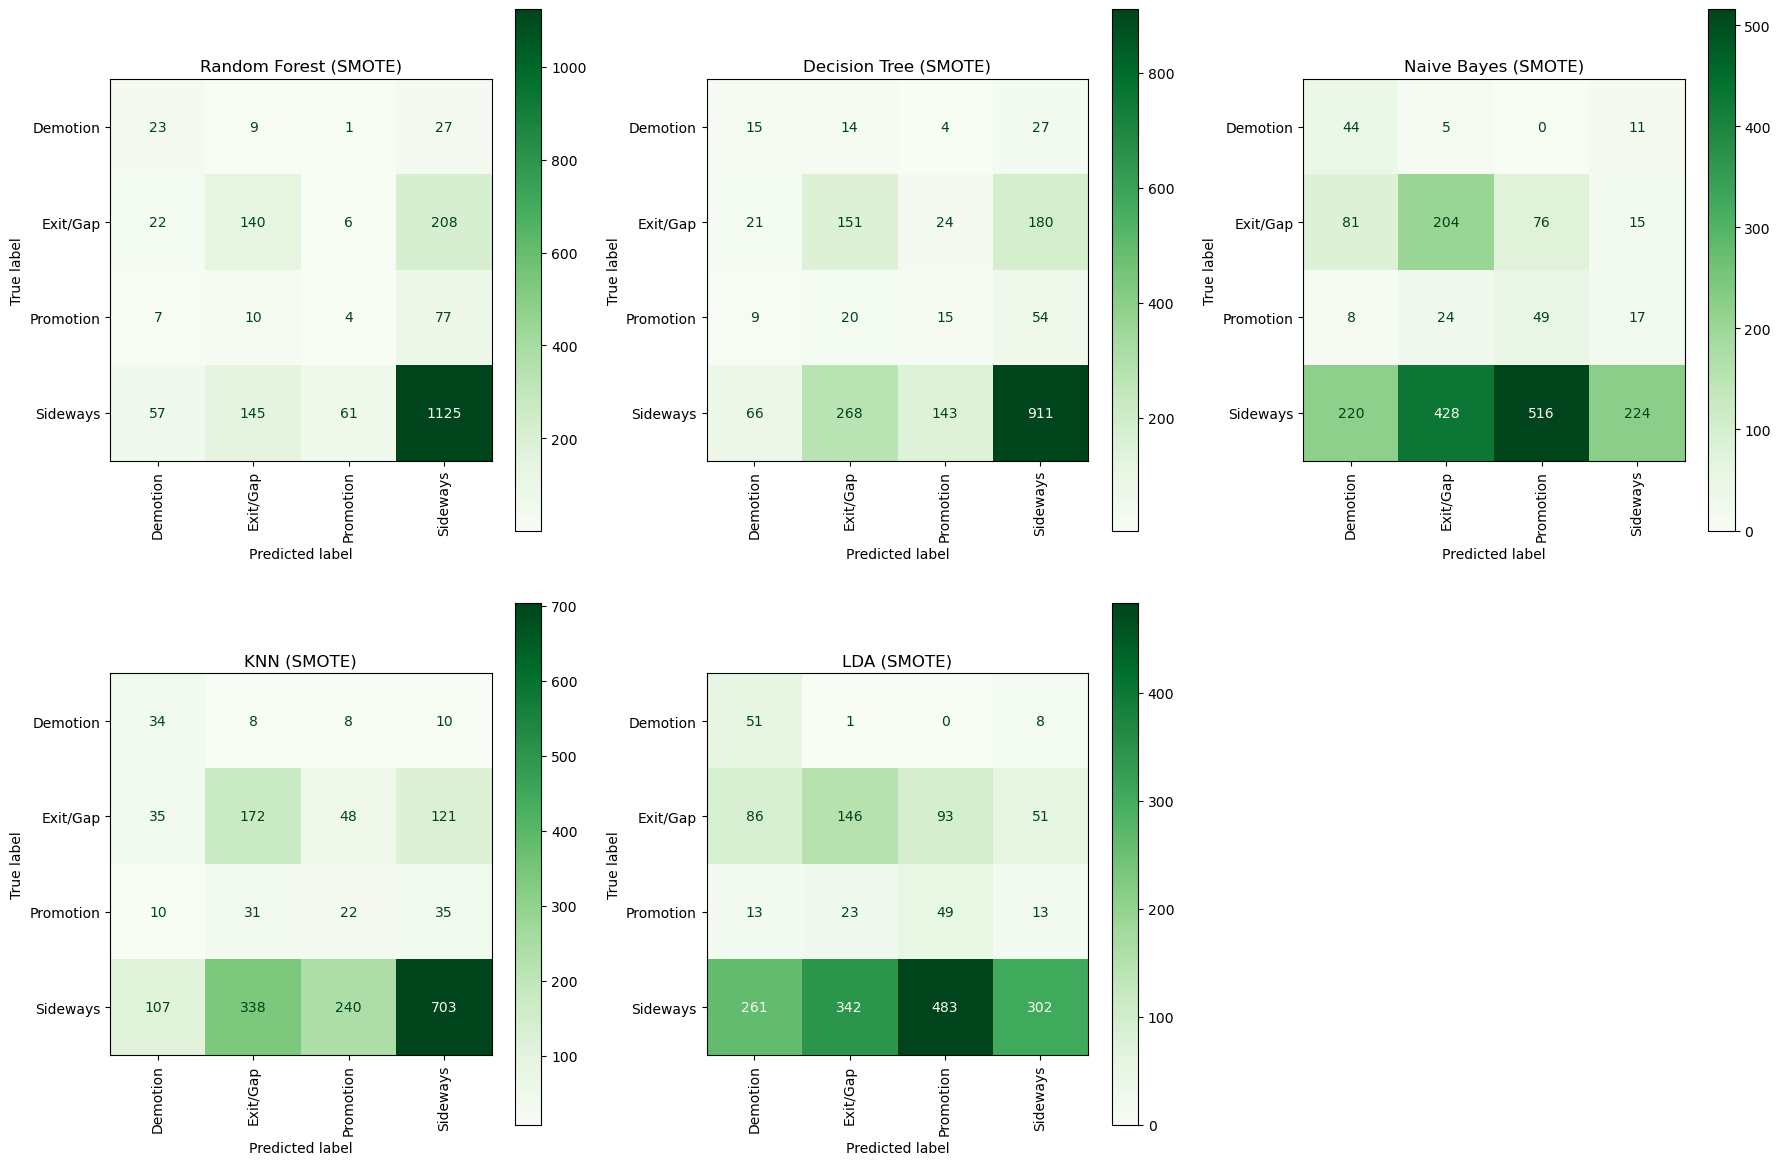

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline

balanced_trees = {
    "Random Forest (Balanced)": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "Decision Tree (Balanced)": DecisionTreeClassifier(random_state=42, class_weight='balanced')
}

print("--- SCENARIO 1: CLASS WEIGHT BALANCING AUDIT ---")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for i, (name, model) in enumerate(balanced_trees.items()):
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    
    # 1. Full Classification Report
    print(f"\n{'='*20} {name.upper()} {'='*20}")
    print(classification_report(y_test, preds))
    
    # 2. Accuracy by Race Audit
    df_audit = X_test.copy()
    df_audit['Correct'] = (preds == y_test.values)
    print(f"Overall Accuracy: {df_audit['Correct'].mean():.2%}")
    print("Accuracy by Race (0=White, 1=Black):")
    print(df_audit.groupby('Race')['Correct'].mean().round(4))
    
    ConfusionMatrixDisplay.from_predictions(y_test, preds, ax=axes[i], cmap='Blues', xticks_rotation='vertical')
    axes[i].set_title(name)

plt.tight_layout()
plt.show()

# Pre-transform for SMOTE
X_train_pre = preprocessor.fit_transform(X_train)
X_test_pre = preprocessor.transform(X_test)

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_pre, y_train)

smote_models = {
    "Random Forest (SMOTE)": RandomForestClassifier(random_state=42),
    "Decision Tree (SMOTE)": DecisionTreeClassifier(random_state=42),
    "Naive Bayes (SMOTE)": GaussianNB(),
    "KNN (SMOTE)": KNeighborsClassifier(n_neighbors=5),
    "LDA (SMOTE)": LinearDiscriminantAnalysis()
}

print("\n--- SCENARIO 2: SMOTE OVERSAMPLING AUDIT ---")
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (name, model) in enumerate(smote_models.items()):
    model.fit(X_resampled, y_resampled)
    preds = model.predict(X_test_pre)
    
    # 1. Full Classification Report
    print(f"\n{'='*20} {name.upper()} {'='*20}")
    print(classification_report(y_test, preds))
    
    # 2. Accuracy by Race Audit
    df_audit_smote = X_test.copy()
    df_audit_smote['Correct'] = (preds == y_test.values)
    print(f"Overall Accuracy: {df_audit_smote['Correct'].mean():.2%}")
    print("Accuracy by Race (0=White, 1=Black):")
    print(df_audit_smote.groupby('Race')['Correct'].mean().round(4))
    
    ConfusionMatrixDisplay.from_predictions(y_test, preds, display_labels=pipe.classes_, 
                                           ax=axes[i], cmap='Greens', xticks_rotation='vertical')
    axes[i].set_title(name)

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

In [23]:
# 1. Update the hierarchy mapping
merged_df = merged_df[merged_df['Role'] != 'ST'].copy()
final_hierarchy = {
    'HC': 5,
    'OC': 4, 'DC': 4,
    'QB': 3,
    'DL': 2, 'WR': 2, 'DB': 2, 'RB': 2,
    'LB': 1, 'OL': 1, 'TE': 1
}

# 2. Re-map Tiers and recalculate Movement
merged_df['Tier'] = merged_df['Role'].map(final_hierarchy)

# Re-sort to ensure temporal consistency for Next_Tier
merged_df = merged_df.sort_values(['CoachID', 'Year'])
merged_df['Next_Tier'] = merged_df.groupby('CoachID')['Tier'].shift(-1)

# 3. Apply the movement logic again with the new 5-tier context
merged_df['Movement'] = merged_df.apply(calculate_forward_movement, axis=1)

# 4. Refresh the Train/Test Split with new labels
# This is crucial so the GridSearch optimizes for the 5-tier transitions
X = merged_df[features]
y = merged_df['Movement']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Hierarchy updated to 5 Tiers for Final Evaluation.")
print("New Class Distribution (Train):")
print(y_train .value_counts())

Hierarchy updated to 5 Tiers for Final Evaluation.
New Class Distribution (Train):
Movement
Sideways     4926
Exit/Gap     1405
Promotion     455
Demotion      293
Name: count, dtype: int64


## 7. Hyperparameter Tuning (GridSearchCV)

In [ ]:
# Random Forest GridSearch — using pipeline so preprocessing is inside CV
rf_pipeline = make_pipeline(RandomForestClassifier(random_state=42))

rf_param_grid = {
    'classifier__n_estimators': np.arange(50,500,50),
    'classifier__max_depth': np.arange(5,50,5),
    'classifier__min_samples_split': np.arange(1,6),
    'classifier__min_samples_leaf': np.arange(2,10),
    'classifier__class_weight': ['balanced', 'balanced_subsample']
}

print("Running Random Forest GridSearch...")
rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=5, n_jobs=-1, scoring='f1_macro')
rf_grid.fit(X_train, y_train)

print(f"\nBest Parameters: {rf_grid.best_params_}")
print(f"Best CV Macro-F1: {rf_grid.best_score_:.4f}")


Running Random Forest GridSearch...


In [ ]:
# Decision Tree GridSearch
dt_pipeline = make_pipeline(DecisionTreeClassifier(random_state=42, class_weight='balanced'))

dt_param_grid = {
    'classifier__max_depth': np.arange(5, 30, 5),
}

print("Running Decision Tree GridSearch...")
dt_grid = GridSearchCV(dt_pipeline, dt_param_grid, cv=5, n_jobs=-1, scoring='f1_macro')
dt_grid.fit(X_train, y_train)

print(f"\nBest Parameters: {dt_grid.best_params_}")
print(f"Best CV Macro-F1: {dt_grid.best_score_:.4f}")


## 8. Final Model Evaluation

In [ ]:
# Use the best model from grid search
best_model = rf_grid.best_estimator_
final_preds = best_model.predict(X_test)

print("Final Optimized Model Performance (Test Set):")
print(classification_report(y_test, final_preds))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, final_preds, display_labels=best_model.classes_, cmap='Blues', xticks_rotation='vertical')
plt.title("Final Random Forest — Confusion Matrix"); plt.show()

# Final bias audit
df_final = X_test.copy()
df_final['Actual'] = y_test
df_final['Predicted'] = final_preds
df_final['Correct'] = df_final['Actual'] == df_final['Predicted']

print("\nAccuracy by Race (0=White, 1=Black):")
print(df_final.groupby('Race')['Correct'].mean().round(4))

mis = df_final[~df_final['Correct']].copy()
mis['Actual_Rank'] = mis['Actual'].map(rank)
mis['Predicted_Rank'] = mis['Predicted'].map(rank)
mis['Error_Type'] = mis.apply(
    lambda r: 'Optimistic' if r['Predicted_Rank'] > r['Actual_Rank'] else 'Pessimistic', axis=1)

print("\nFinal Bias Summary (% of errors per group):")
bias_table = mis.groupby(['Race', 'Error_Type']).size().unstack(fill_value=0)
display(bias_table.div(bias_table.sum(axis=1), axis=0).mul(100).round(2))


## 9. Feature Importance Analysis

In [ ]:
# Extract the classifier from the pipeline
final_rf = best_model.named_steps['classifier']

# MDI importance
mdi = final_rf.feature_importances_

# Permutation importance (on preprocessed test data)
X_test_processed = best_model.named_steps['preprocessor'].transform(X_test)
perm = permutation_importance(final_rf, X_test_processed, y_test,
                               n_repeats=10, random_state=42, n_jobs=-1, scoring='f1_macro')

importance_df = pd.DataFrame({
    'Feature': features,
    'MDI_Importance': mdi,
    'Permutation_Importance': perm.importances_mean,
    'Perm_Std': perm.importances_std
}).sort_values('Permutation_Importance', ascending=False)

print("--- Feature Importance Comparison ---")
display(importance_df.reset_index(drop=True))
